# `train_model.ipynb` — Random Forest with Hyperparameter Tuning
## Driver Alert & Feedback Management App
---
**Pipeline position:** This notebook runs *after* `process_data.py` has created `training_data.json`.

| Step | What happens |
|---|---|
| 1–4 | Load JSON → build DataFrame → split 80/20 |
| 5 | Train **baseline** RF (original 100-tree settings) |
| 6–9 | **RandomizedSearchCV** — tries 20 hyperparameter combos using 3-fold CV |
| 10–13 | Train **tuned** RF with best params found |
| 14–17 | Compare: metrics bar chart, confusion matrices, ROC-AUC, feature importance |
| 18 | 5-fold CV stability check |
| 19 | Save both models to `.pkl` |

## 1. Imports

In [ ]:
import pandas as pd          # converts JSON into a DataFrame
import numpy as np           # numerical operations used by sklearn
import json
import m2cgen as m2c
import seaborn as sns        # makes statistical plots
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split,        # splits 80/20
                                       RandomizedSearchCV,      # tries N random hyperparameter combos
                                       cross_val_score)         # k-fold stability check
from sklearn.ensemble         import RandomForestClassifier    # the RF algorithm
from sklearn.metrics          import (classification_report,   # per-class P/R/F1
                                       confusion_matrix,        # where it got confused
                                       accuracy_score,          # overall %
                                       precision_score,
                                       recall_score,
                                       f1_score,
                                       roc_curve,
                                       roc_auc_score)
from sklearn.preprocessing    import label_binarize            # needed for ROC-AUC multi-class
import joblib                 # save / load trained model (.pkl)

print("All libraries loaded ✅")

All libraries loaded ✅


## 2. Load Data & Prepare Features
*(Loads from `training_data.json` — run `process_data.py` first)*

In [ ]:
# ── 1. Load the processed data (same source as original train_ambulance_ai) ──
print("Loading training_data.json...")
try:
    with open('training_data.json', 'r') as f:   # JSON file created by process_data.py
        data = json.load(f)                        # loads all training samples
except FileNotFoundError:
    print("Error: 'training_data.json' not found. Run process_data.py first!")
    raise

df = pd.DataFrame(data)   # converts JSON samples into an Excel-like table (ML-friendly)

# ── 2. Sanity check ───────────────────────────────────────────────────────────
print(f"\nTotal Samples: {len(df)}")
print("\nClass Distribution:")
print(df['label'].value_counts())

# ── 3. Prepare inputs (X) and outputs (y) ────────────────────────────────────
X = df.drop(columns=['label'])   # numeric feature columns only (avg_speed, max_force …)
y = df['label']                   # correct driving class for each window

# ── 4. Train / test split — identical seed to original notebook ───────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20 % held-out for evaluation
    random_state=42    # fixed seed → reproducible results every run
)

print(f"\nTrain: {len(X_train)} samples  |  Test: {len(X_test)} samples")
print(f"Features : {list(X.columns)}")

Loading training_data.json...

Total Samples: 9433

Class Distribution:
label
Cruising      6380
Lane Left     1091
Braking        985
Lane Right     977
Name: count, dtype: int64

Train: 7546 samples  |  Test: 1887 samples
Features : ['avg_speed', 'max_force', 'std_force', 'min_force', 'avg_jerk', 'avg_lateral', 'max_lateral']


## 3. Baseline Random Forest
*(Original settings — used as the benchmark to beat)*

In [3]:
# ── Class weights (same as original train_ambulance_ai) ───────────────────────
# Tells the model: "pay MORE attention to rare but safety-critical classes"
class_weights = {
    'Cruising':   1,    # very common → normal weight
    'Braking':    3,    # less common → 3× more attention
    'Lane Left':  10,   # rare → force model to prioritise
    'Lane Right': 10,   # rare → force model to prioritise
    'Pullover':   15,   # very rare → highest priority
}

# ── 5. Train BASELINE Random Forest (original 100-tree settings) ──────────────
print("Training baseline Random Forest (original settings)…")
rf_baseline = RandomForestClassifier(
    n_estimators = 100,           # 100 decision trees
    class_weight = class_weights, # safety-critical weighting
    random_state = 42,            # reproducibility
    n_jobs       = -1,            # use all CPU cores
)
rf_baseline.fit(X_train, y_train)   # model learns patterns from training data

y_pred_base = rf_baseline.predict(X_test)

# Compute all four key metrics
base_acc  = accuracy_score(y_test, y_pred_base)
base_prec = precision_score(y_test, y_pred_base, average='weighted', zero_division=0)
base_rec  = recall_score(y_test, y_pred_base,    average='weighted', zero_division=0)
base_f1   = f1_score(y_test, y_pred_base,        average='weighted', zero_division=0)

print("\n--- BASELINE MODEL REPORT CARD ---")
print(f"Overall Accuracy : {base_acc:.2%}")
print(f"Precision        : {base_prec:.4f}")
print(f"Recall           : {base_rec:.4f}")
print(f"F1-Score         : {base_f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_base, zero_division=0))
print("\nConfusion Matrix (Rows=Actual, Cols=Predicted):")
print(confusion_matrix(y_test, y_pred_base))

Training baseline Random Forest (original settings)…



--- BASELINE MODEL REPORT CARD ---
Overall Accuracy : 80.02%
Precision        : 0.8098
Recall           : 0.8002
F1-Score         : 0.7619

Detailed Report:
              precision    recall  f1-score   support

     Braking       0.88      0.74      0.81       198
    Cruising       0.79      0.98      0.87      1292
   Lane Left       0.80      0.24      0.36       204
  Lane Right       0.89      0.24      0.38       193

    accuracy                           0.80      1887
   macro avg       0.84      0.55      0.61      1887
weighted avg       0.81      0.80      0.76      1887


Confusion Matrix (Rows=Actual, Cols=Predicted):
[[ 147   49    1    1]
 [  10 1268   10    4]
 [   1  154   48    1]
 [   9  136    1   47]]


## Hyperparameter Tuning — RandomizedSearchCV

### What is a hyperparameter?
Regular parameters are **learned by the model** from data (e.g. which feature to split on).  
Hyperparameters are **set by you before training** — they control *how* the model learns.  
For Random Forest the key ones are:

| Hyperparameter | What it controls | Default |
|---|---|---|
| `n_estimators` | Number of trees in the forest | 100 |
| `max_depth` | How deep each tree can grow (deeper = more complex) | None (unlimited) |
| `min_samples_split` | Min samples needed to split a node | 2 |
| `min_samples_leaf` | Min samples required at a leaf (end) node | 1 |
| `max_features` | How many features each tree considers at each split | "sqrt" |
| `bootstrap` | Whether trees train on random subsamples of data | True |

### Why RandomizedSearchCV and not GridSearchCV?
**GridSearchCV** tries *every* combination — with 6 parameters and 3–4 values each that's  
4×4×3×3×3×2 = **864 combinations × 3 folds = 2,592 model fits**. Too slow.  

**RandomizedSearchCV** randomly samples `n_iter` combinations and uses **cross-validation**  
to score each one. With `n_iter=20` you test 20×3 = **60 fits** and still find a near-optimal result.


## 4. Define Search Space & Run RandomizedSearchCV

In [ ]:
#Define the hyperparameter search space
# Each key = one hyperparameter; each value = list of options to randomly sample from
param_distributions = {
    'n_estimators':      [50, 100, 200, 300],       # more trees = more robust (but slower)
    'max_depth':         [None, 10, 20, 30],         # None = tree grows until pure leaves
    'min_samples_split': [2, 5, 10],                 # higher = simpler trees, less overfitting
    'min_samples_leaf':  [1, 2, 4],                  # higher = smoother decision boundaries
    'max_features':      ['sqrt', 'log2', None],     # sqrt = classic RF; None = use all features
    'bootstrap':         [True, False],              # False = each tree sees full training set
}

#Base estimator — class weights are always kept fixed 
base_rf = RandomForestClassifier(
    class_weight = class_weights,   # safety weighting never changes during search
    random_state = 42,
    n_jobs       = -1,
)

#RandomizedSearchCV setup
random_search = RandomizedSearchCV(
    estimator           = base_rf,
    param_distributions = param_distributions,
    n_iter              = 20,          # test 20 random combinations
    cv                  = 3,           # 3-fold cross-validation on each combo
    scoring             = 'accuracy',  # optimise for accuracy (change to 'f1_weighted' if preferred)
    random_state        = 42,          # reproducible sampling
    n_jobs              = -1,          # parallelise across all CPU cores
    verbose             = 1,           # prints progress
    return_train_score  = True,        # lets us inspect overfitting later
)

#Run the search 
print("Running RandomizedSearchCV  (20 combos × 3-fold CV = 60 fits)…")
print("Estimated time: 3–6 minutes depending on your machine.\n")

import time
t0 = time.time()
random_search.fit(X_train, y_train)   # fits all 60 models, picks the best
elapsed = time.time() - t0

print(f"\n✅ Search completed in {elapsed:.1f}s")
print(f"\n--- BEST HYPERPARAMETERS FOUND ---")
for param, value in random_search.best_params_.items():
    print(f"  {param:22s}: {value}")
print(f"\nBest cross-validation accuracy: {random_search.best_score_:.4f}")

Running RandomizedSearchCV  (20 combos × 3-fold CV = 60 fits)…
Estimated time: 3–6 minutes depending on your machine.

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Search completed in 52.0s

--- BEST HYPERPARAMETERS FOUND ---
  n_estimators          : 100
  min_samples_split     : 5
  min_samples_leaf      : 2
  max_features          : log2
  max_depth             : None
  bootstrap             : False

Best cross-validation accuracy: 0.7915


## 5. Visualise All 20 CV Combinations
*(See which combos scored best and how much variance exists)*

Top 5 combinations:
 mean_test_score  std_test_score  param_n_estimators param_max_depth  param_min_samples_split  param_min_samples_leaf param_max_features  param_bootstrap
        0.791545        0.002654                 100            None                        5                       2               log2            False
        0.776172        0.002855                 300              20                       10                       1                NaN             True
        0.774847        0.001032                 200              20                       10                       1                NaN             True
        0.774582        0.006515                 200              30                       10                       2               sqrt            False
        0.765173        0.003969                 100              20                       10                       2                NaN             True


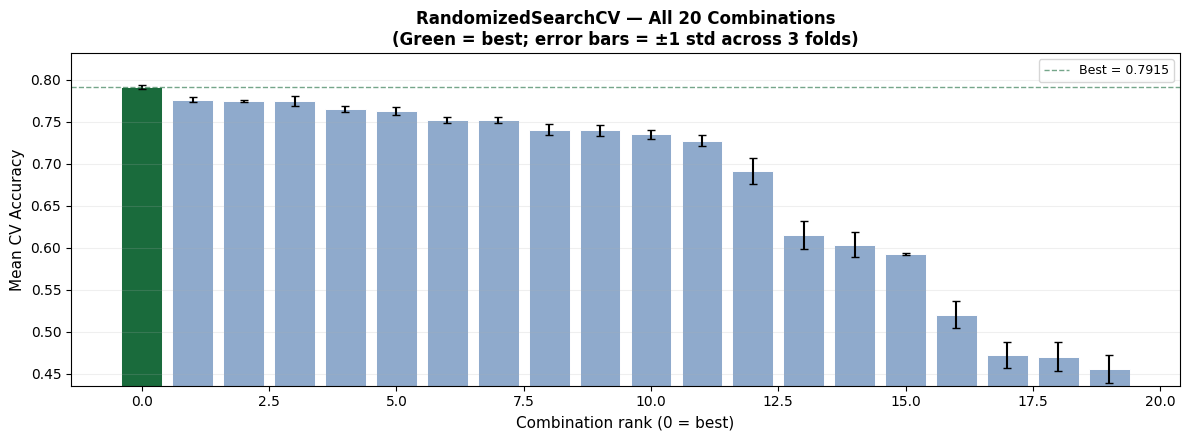

In [ ]:
#Visualise all 20 CV results
# Shows which combinations scored well so can see how sensitive the search was
import pandas as pd
cv_df = (pd.DataFrame(random_search.cv_results_)
           .sort_values('mean_test_score', ascending=False)
           .reset_index(drop=True))

print("Top 5 combinations:")
top_cols = ['mean_test_score','std_test_score',
            'param_n_estimators','param_max_depth',
            'param_min_samples_split','param_min_samples_leaf',
            'param_max_features','param_bootstrap']
print(cv_df[top_cols].head(5).to_string(index=False))

#Plot
fig, ax = plt.subplots(figsize=(12, 4.5))
colors = ['#1a6b3c' if i == 0 else '#8faacc' for i in range(len(cv_df))]
ax.bar(range(len(cv_df)), cv_df['mean_test_score'],
       yerr=cv_df['std_test_score'],
       color=colors, edgecolor='white', linewidth=0.7, capsize=3)
ax.axhline(random_search.best_score_, color='#1a6b3c',
           linestyle='--', linewidth=1, alpha=0.6, label=f'Best = {random_search.best_score_:.4f}')
ax.set_xlabel('Combination rank (0 = best)', fontsize=11)
ax.set_ylabel('Mean CV Accuracy', fontsize=11)
ax.set_title('RandomizedSearchCV — All 20 Combinations\n'
             '(Green = best; error bars = ±1 std across 3 folds)',
             fontsize=12, fontweight='bold')
ax.set_ylim(cv_df['mean_test_score'].min() - 0.02,
            cv_df['mean_test_score'].max() + 0.04)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('tuning_cv_results.png', dpi=150)
plt.show()

## 6. Train Tuned Model with Best Parameters

In [ ]:
# random_search.best_estimator_ is already re-fitted on the full X_train
rf_tuned = random_search.best_estimator_

print("Best model parameters:")
print(f"  n_estimators     : {rf_tuned.n_estimators}")
print(f"  max_depth        : {rf_tuned.max_depth}")
print(f"  min_samples_split: {rf_tuned.min_samples_split}")
print(f"  min_samples_leaf : {rf_tuned.min_samples_leaf}")
print(f"  max_features     : {rf_tuned.max_features}")
print(f"  bootstrap        : {rf_tuned.bootstrap}")

#Evaluate tuned model on the same test set 
y_pred_tuned = rf_tuned.predict(X_test)

tuned_acc  = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned,  zero_division=0)
tuned_rec  = recall_score(y_test, y_pred_tuned, zero_division=0)
tuned_f1   = f1_score(y_test, y_pred_tuned,zero_division=0)

print("\n--- TUNED MODEL REPORT CARD ---")
print(f"Overall Accuracy : {tuned_acc:.2%}")
print(f"Precision        : {tuned_prec:.4f}")
print(f"Recall           : {tuned_rec:.4f}")
print(f"F1-Score         : {tuned_f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_tuned, zero_division=0))
print("\nConfusion Matrix (Rows=Actual, Cols=Predicted):")
print(confusion_matrix(y_test, y_pred_tuned))

Best model parameters:
  n_estimators     : 100
  max_depth        : None
  min_samples_split: 5
  min_samples_leaf : 2
  max_features     : log2
  bootstrap        : False

--- TUNED MODEL REPORT CARD ---
Overall Accuracy : 82.88%
Precision        : 0.8236
Recall           : 0.8288
F1-Score         : 0.8177

Detailed Report:
              precision    recall  f1-score   support

     Braking       0.88      0.75      0.81       198
    Cruising       0.84      0.94      0.89      1292
   Lane Left       0.71      0.50      0.59       204
  Lane Right       0.79      0.48      0.60       193

    accuracy                           0.83      1887
   macro avg       0.80      0.67      0.72      1887
weighted avg       0.82      0.83      0.82      1887


Confusion Matrix (Rows=Actual, Cols=Predicted):
[[ 149   44    3    2]
 [  14 1220   37   21]
 [   1   99  103    1]
 [   5   93    3   92]]


## 7. Baseline vs Tuned - Metric Comparison

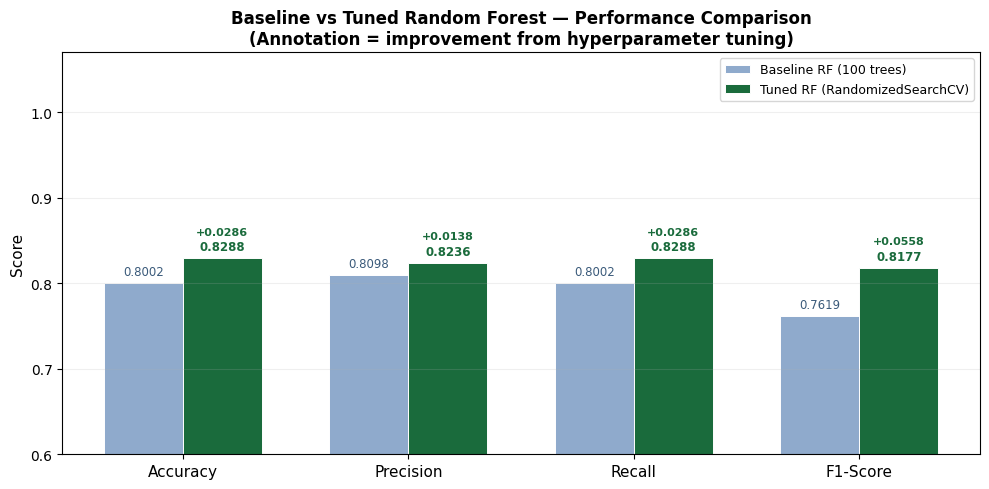


Summary:
  Metric         Baseline      Tuned      Delta
  --------------------------------------------
  Accuracy         0.8002     0.8288    +0.0286
  Precision        0.8098     0.8236    +0.0138
  Recall           0.8002     0.8288    +0.0286
  F1-Score         0.7619     0.8177    +0.0558


In [ ]:
#Baseline vs Tuned — side-by-side metric comparison
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
base_vals    = [base_acc,   base_prec,   base_rec,  base_f1]
tuned_vals   = [tuned_acc,  tuned_prec,  tuned_rec, tuned_f1]

x = np.arange(len(metric_names))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, base_vals,  w, label='Baseline RF (100 trees)',
            color='#8faacc', edgecolor='white', linewidth=0.7)
b2 = ax.bar(x + w/2, tuned_vals, w, label='Tuned RF (RandomizedSearchCV)',
            color='#1a6b3c', edgecolor='white', linewidth=0.7)

# Value labels on each bar
for bar, v in zip(b1, base_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.006,
            f'{v:.4f}', ha='center', va='bottom', fontsize=8.5, color='#3a5a7a')
for bar, v in zip(b2, tuned_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.006,
            f'{v:.4f}', ha='center', va='bottom', fontsize=8.5,
            color='#1a6b3c', fontweight='bold')

# Delta annotations above the tuned bars
for i, (bv, tv) in enumerate(zip(base_vals, tuned_vals)):
    diff  = tv - bv
    sign  = '+' if diff >= 0 else ''
    color = '#1a6b3c' if diff >= 0 else '#c0392b'
    ax.annotate(f'{sign}{diff:.4f}',
                xy=(i + w/2, tv + 0.028),
                ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0.60, 1.07)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Baseline vs Tuned Random Forest — Performance Comparison\n'
             '(Annotation = improvement from hyperparameter tuning)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150)
plt.show()

#Print delta table
print("\nSummary:")
print(f"  {'Metric':<12} {'Baseline':>10} {'Tuned':>10} {'Delta':>10}")
print("  " + "-"*44)
for name, bv, tv in zip(metric_names, base_vals, tuned_vals):
    sign = '+' if tv-bv >= 0 else ''
    print(f"  {name:<12} {bv:>10.4f} {tv:>10.4f} {sign+f'{tv-bv:.4f}':>10}")

## 8. Confusion Matrices - Baseline vs Tuned
*(Rows = actual class, Cols = predicted class — diagonal = correct predictions)*

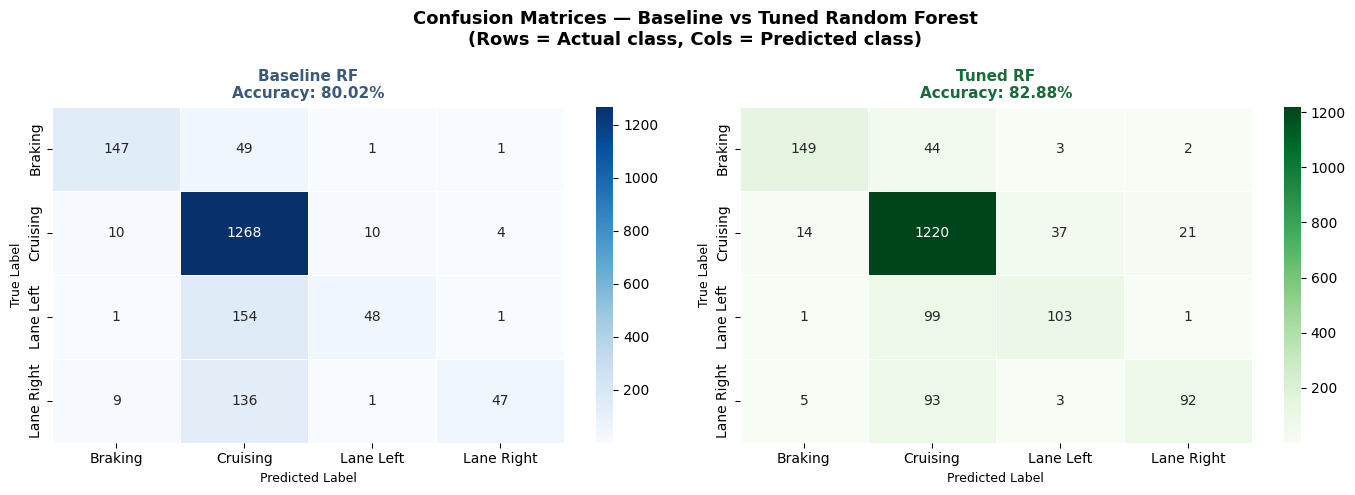

In [8]:
# ── 14. Confusion matrices — baseline vs tuned ────────────────────────────────
classes = sorted(y.unique().tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title, cmap in [
    (axes[0], y_pred_base,  'Baseline RF',  'Blues'),
    (axes[1], y_pred_tuned, 'Tuned RF',     'Greens'),
]:
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, ax=ax, cbar=True, annot_kws={'size': 10})
    acc_val = accuracy_score(y_test, y_pred)
    ax.set_title(f'{title}\nAccuracy: {acc_val:.2%}',
                 fontsize=11, fontweight='bold',
                 color='#1a6b3c' if 'Tuned' in title else '#3a5a7a')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

fig.suptitle('Confusion Matrices — Baseline vs Tuned Random Forest\n'
             '(Rows = Actual class, Cols = Predicted class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_confusion_matrices.png', dpi=150)
plt.show()

## 9. ROC-AUC Curves — Baseline vs Tuned
*(Higher AUC = better ability to separate that class from all others)*

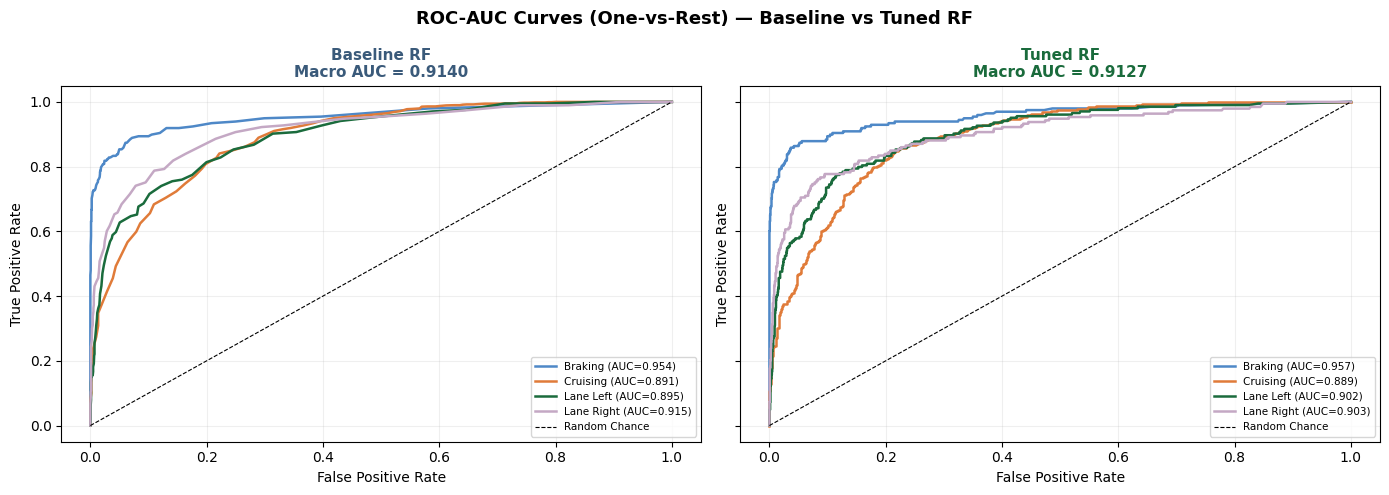

In [9]:
# ── 15. ROC-AUC curves — baseline vs tuned ───────────────────────────────────
# label_binarize turns "Braking/Cruising/…" into a binary column per class
# needed because roc_curve() only works with binary labels
y_bin    = label_binarize(y_test, classes=classes)
palette  = ['#4e88c7', '#e07b39', '#1a6b3c', '#c4a8c4']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (model_obj, y_pred_obj, title) in zip(axes, [
    (rf_baseline, y_pred_base,  'Baseline RF'),
    (rf_tuned,    y_pred_tuned, 'Tuned RF'),
]):
    cls_list = list(model_obj.classes_)
    y_prob_m = model_obj.predict_proba(X_test)

    # Align probability columns to sorted class order
    prob_aligned = np.zeros((len(y_test), len(classes)))
    for ci, c in enumerate(classes):
        if c in cls_list:
            prob_aligned[:, ci] = y_prob_m[:, cls_list.index(c)]

    # Plot one ROC curve per class (One-vs-Rest)
    for ci, (cls, col) in enumerate(zip(classes, palette)):
        fpr, tpr, _ = roc_curve(y_bin[:, ci], prob_aligned[:, ci])
        auc_val     = roc_auc_score(y_bin[:, ci], prob_aligned[:, ci])
        ax.plot(fpr, tpr, linewidth=1.8, label=f'{cls} (AUC={auc_val:.3f})', color=col)

    macro_auc = roc_auc_score(y_bin, prob_aligned, average='macro', multi_class='ovr')
    ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random Chance')
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'{title}\nMacro AUC = {macro_auc:.4f}',
                 fontsize=11, fontweight='bold',
                 color='#1a6b3c' if 'Tuned' in title else '#3a5a7a')
    ax.legend(fontsize=7.5, loc='lower right'); ax.grid(alpha=0.2)

fig.suptitle('ROC-AUC Curves (One-vs-Rest) — Baseline vs Tuned RF',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tuning_roc_auc.png', dpi=150)
plt.show()

## 10. Feature Importance — Baseline vs Tuned
*(Did tuning change which sensors the model relies on?)*

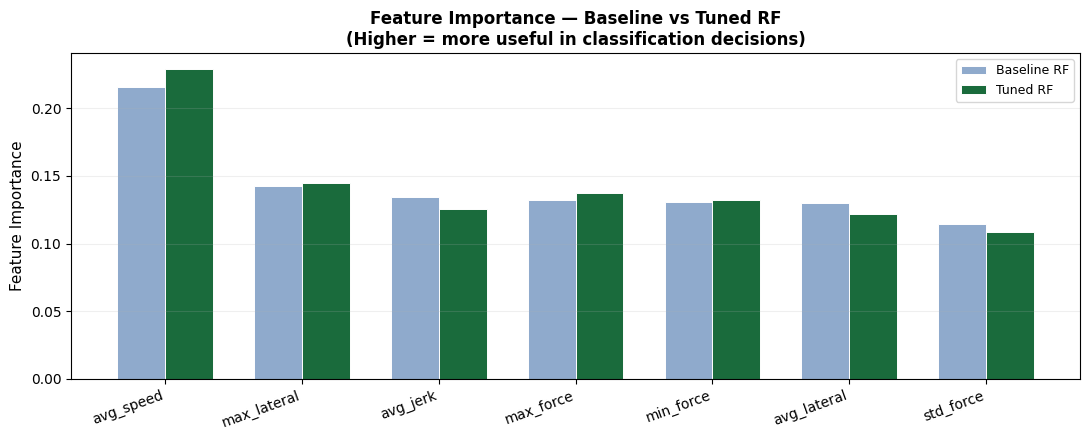


--- SENSOR IMPORTANCE (Tuned Model) ---
1. avg_speed: 0.2293
2. max_lateral: 0.1449
3. max_force: 0.1377
4. min_force: 0.1322
5. avg_jerk: 0.1258
6. avg_lateral: 0.1218
7. std_force: 0.1084


In [10]:
# ── 16. Feature Importance — Baseline vs Tuned ────────────────────────────────
# Shows how useful each sensor feature was for making correct predictions.
# Did tuning change which sensors the model relies on?
feat_names = list(X.columns)
base_imp   = pd.Series(rf_baseline.feature_importances_, index=feat_names).sort_values(ascending=False)
tuned_imp  = pd.Series(rf_tuned.feature_importances_,    index=feat_names).reindex(base_imp.index)

x = np.arange(len(feat_names)); w = 0.35

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - w/2, base_imp.values,  w, label='Baseline RF',
       color='#8faacc', edgecolor='white', linewidth=0.7)
ax.bar(x + w/2, tuned_imp.values, w, label='Tuned RF',
       color='#1a6b3c', edgecolor='white', linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(base_imp.index, rotation=20, ha='right')
ax.set_ylabel('Feature Importance', fontsize=11)
ax.set_title('Feature Importance — Baseline vs Tuned RF\n'
             '(Higher = more useful in classification decisions)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('tuning_feature_importance.png', dpi=150)
plt.show()

print("\n--- SENSOR IMPORTANCE (Tuned Model) ---")
for rank, (feat, imp) in enumerate(tuned_imp.sort_values(ascending=False).items(), 1):
    print(f"{rank}. {feat}: {imp:.4f}")

## 11. 5-Fold Cross-Validation — Stability Check
*(Consistent scores across folds = model generalises well, not just memorising training data)*

Running 5-fold cross-validation on tuned model…

CV scores per fold : ['0.6677', '0.6905', '0.6698', '0.6824', '0.7078']
Mean CV accuracy   : 0.6837  ±  0.0147
Min / Max          : 0.6677  /  0.7078


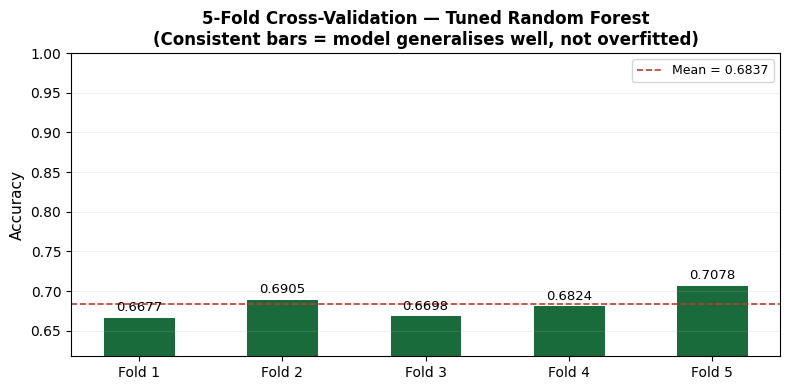

In [11]:
# ── 17. 5-Fold Cross-Validation — Is the tuned model stable? ─────────────────
# cross_val_score splits the FULL dataset into 5 chunks.
# Trains on 4, tests on 1, repeats 5 times. Consistent scores = not overfitted.
print("Running 5-fold cross-validation on tuned model…")

cv_scores = cross_val_score(
    RandomForestClassifier(
        **random_search.best_params_,   # unpack best hyperparameters
        class_weight = class_weights,
        random_state = 42,
        n_jobs       = -1,
    ),
    X, y,                # use entire dataset (not just train split)
    cv      = 5,
    scoring = 'accuracy',
    n_jobs  = -1,
)

print(f"\nCV scores per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean CV accuracy   : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
print(f"Min / Max          : {cv_scores.min():.4f}  /  {cv_scores.max():.4f}")

# ── Visualise CV stability ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([f'Fold {i+1}' for i in range(5)], cv_scores,
              color='#1a6b3c', edgecolor='white', linewidth=0.7, width=0.5)
for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{score:.4f}', ha='center', va='bottom', fontsize=9.5)
ax.axhline(cv_scores.mean(), color='#c0392b', linestyle='--', linewidth=1.2,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_ylim(cv_scores.min() - 0.05, 1.0)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('5-Fold Cross-Validation — Tuned Random Forest\n'
             '(Consistent bars = model generalises well, not overfitted)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('tuning_cv_stability.png', dpi=150)
plt.show()

## 12. Save Models

In [ ]:
# ── 18. Save both models ──────────────────────────────────────────────────────
joblib.dump(rf_baseline, 'ambulance_model.pkl')         # original (keep compatibility)
joblib.dump(rf_tuned,    'ambulance_model_tuned.pkl')   # tuned version
js_code = m2c.export_to_javascript(rf_tuned)
final_js = "export default " + js_code
with open('ambulance_model_tuned.js', 'w') as f:
    f.write(final_js)

print("[SUCCESS] ambulance_model.pkl        → original baseline")
print("[SUCCESS] ambulance_model_tuned.pkl  → tuned model (use this one)")
print()
print("To load and use the tuned model later:")
print("  import joblib")
print("  model = joblib.load('ambulance_model_tuned.pkl')")
print("  prediction = model.predict(your_features_dataframe)")

# ── Final summary ─────────────────────────────────────────────────────────────
print()
print("=" * 55)
print("              TUNING SUMMARY")
print("=" * 55)
print(f"  Baseline accuracy : {base_acc:.4f}  ({base_acc:.2%})")
print(f"  Tuned accuracy    : {tuned_acc:.4f}  ({tuned_acc:.2%})")
print(f"  Improvement       : +{tuned_acc - base_acc:.4f} pp")
print(f"  Baseline F1       : {base_f1:.4f}")
print(f"  Tuned F1          : {tuned_f1:.4f}")
print(f"  Best params       :")
for k, v in random_search.best_params_.items():
    print(f"    {k:22s}: {v}")
print("=" * 55)

[SUCCESS] ambulance_model.pkl        → original baseline
[SUCCESS] ambulance_model_tuned.pkl  → tuned model (use this one)

To load and use the tuned model later:
  import joblib
  model = joblib.load('ambulance_model_tuned.pkl')
  prediction = model.predict(your_features_dataframe)

              TUNING SUMMARY
  Baseline accuracy : 0.8002  (80.02%)
  Tuned accuracy    : 0.8288  (82.88%)
  Improvement       : +0.0286 pp
  Baseline F1       : 0.7619
  Tuned F1          : 0.8177
  Best params       :
    n_estimators          : 100
    min_samples_split     : 5
    min_samples_leaf      : 2
    max_features          : log2
    max_depth             : None
    bootstrap             : False
